<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Multi-Crop-Ranking/Multi_Crop_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import libraries**

In [111]:
!pip install lightgbm

import pandas as pd
import numpy as np
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


**Load Data**

In [124]:
try:
    crop_req = pd.read_csv("/content/drive/MyDrive/DSGP/Crop_training_data_full.csv")
    print("Dataset loaded correctly")
    print(crop_req.shape)

except Exception as e:
    print("Dataset loading failed:", e)

crop_req.head()

Dataset loaded correctly
(2100, 18)


,crop,temperature,rainfall,ph,organic_carbon,cec,awc,bulk_density,texture,texture_num,texture_tolerance,texture_tol_num,rooting_depth,root_depth_num,sun_req,sun_req_num,suitability_score,suitability_class
0,Banana,24.218789,1514.490115,8.139456,1.487176,35.074121,0.321336,1.452704,Clayey loam,4,High,3,Deep,4,High,3,0.949,Suitable
1,Mangosteen,27.241423,1927.666758,5.172037,3.984712,16.122542,0.284810,0.982135,Heavy clay,5,High,3,Medium,2,Medium,2,0.914,Suitable
2,Okra,22.506573,983.720536,7.669090,3.914564,9.949383,0.333349,1.628292,Sandy loam,2,Medium,2,Medium,2,High,3,0.678,Unsuitable
3,Luffa,37.964878,2466.376956,7.990884,1.828160,29.958186,0.095352,1.542933,Loam,3,High,3,Shallow,1,High,3,0.692,Unsuitable
4,Sweet Potato,21.852794,1482.314049,6.965394,2.453519,12.637792,0.390210,1.212753,Clayey loam,4,High,3,Shallow,1,High,3,0.655,Unsuitable


**Convert Suitability Score To Ranking Label**

In [125]:
def to_rank(score):
    if score >= 0.8:
        return 3
    elif score >= 0.6:
        return 2
    elif score >= 0.4:
        return 1
    else:
        return 0

crop_req["rank_label"] = crop_req["suitability_score"].apply(to_rank)

**Define Features**

In [126]:
FEATURES = [
    "temperature",
    "rainfall",
    "ph",
    "organic_carbon",
    "cec",
    "awc",
    "bulk_density"
]

X = crop_req[FEATURES]
y = crop_req["rank_label"]

**Define Query Groups**

In [127]:
# Each group compares all crops for one condition
GROUP_SIZE = len(crop_req["crop"].unique())

groups = [GROUP_SIZE] * (len(crop_req) // GROUP_SIZE)

**Create LightGBM Dataset**

In [128]:
train_data = lgb.Dataset(
    X,
    label=y,
    group=groups
)

**LambdaMART Parameters**

In [129]:
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [3, 5],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 20,
    "verbosity": -1
}

**Train Model**

In [130]:
model = lgb.train(
    params,
    train_data,
    num_boost_round=200
)

**Rank Crops**

In [131]:
crop_req["rank_score"] = model.predict(X)

ranked = crop_req.sort_values("rank_score", ascending=False)
ranked[["crop", "rank_score"]].head(5)

,crop,rank_score
1097,Manioc,3.271517
1880,Turmeric,3.191194
1689,Luffa,3.139678
1763,Turmeric,3.054927
1074,Mangosteen,3.003229


**Suitability Score Histogram**

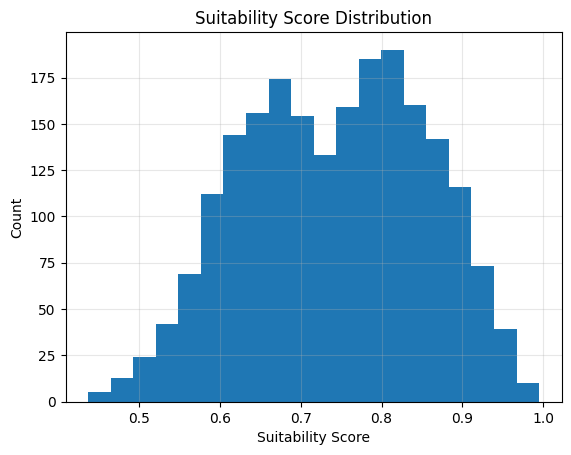

In [136]:
plt.figure()
plt.hist(crop_req["suitability_score"], bins=20)
plt.title("Suitability Score Distribution")
plt.xlabel("Suitability Score")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


**Feature Importance Plot**

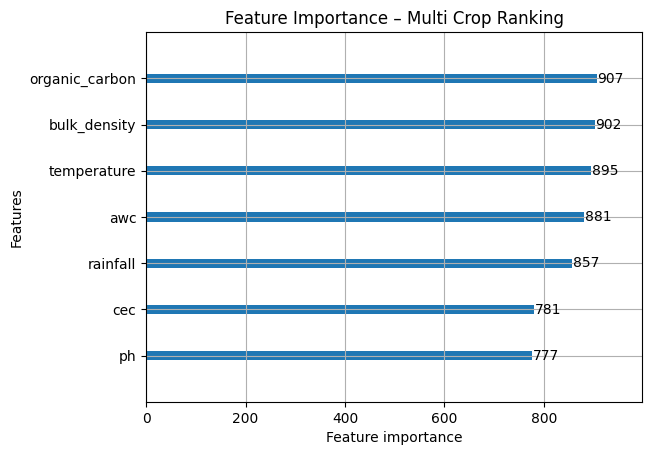

In [140]:
lgb.plot_importance(model, max_num_features=10)
plt.title("Feature Importance – Multi Crop Ranking")
plt.show()


**Correlation Heatmap**

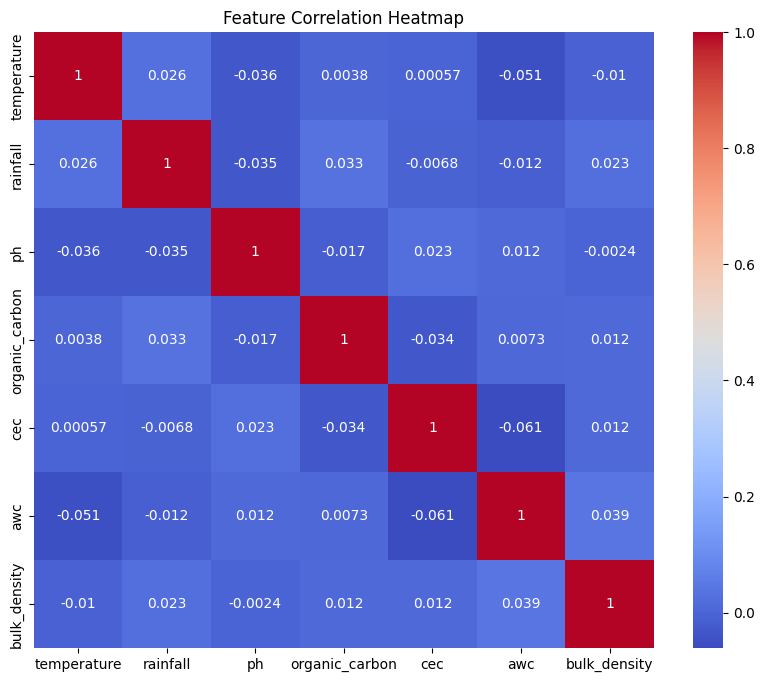

In [141]:
plt.figure(figsize=(10,8))
sns.heatmap(crop_req[FEATURES].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()